<h1>Project 2: Planetary Orbits</h1>

This project will focus on simulating planetary motion in the Solar System due to gravitational 
forces. 

<H3>Imports</H3>

In [1]:
from vpython import *
import copy 

C:\Users\auher\anaconda3\envs\myenv\lib\site-packages\vpython\__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<IPython.core.display.Javascript object>

<h3>Constants</h3>

In [2]:
#From website cited/lecture
#Gravitational constant (m^3 * kg^(-1) * s^2)
G = 6.674e-11
#Earth mass (kg)
M_earth = 5.972e24
#Earth radius (m)
R_earth = 6.371e6

#Ball starts in altitude (200km), value used for good visualization
altitude = 2e5
r = R_earth + altitude

<h3>Part 1: Newton's Cannonball</h3>

Values used for calculation as well as checking for the velocity values can be found at the website provided: https://asklearn.xyz/calculators/escape-velocity/. 

Each scneario we need to test for can have its own simulation. We will want a test for not enetering orbit and crashing back down to earth, a test for entering a fixed orbit, a test for an eliptical orbit, and a test for leaving our orbit. Each will produce a visual simulation as well as values to support calculations

In [3]:
# Calculate orbital and escape velocities
# v = sqrt((g * M)/r)
v_orbital = sqrt(G * M_earth / r)
print(f"Orbital velocity: {v_orbital:.2f} m/s")

# v = sqrt((2*g*M)/r)
v_exit = sqrt(2 * G * M_earth / r)
print(f"Escape velocity: {v_exit:.2f} m/s")

Orbital velocity: 7788.20 m/s
Escape velocity: 11014.18 m/s


Orbital velocity = 7788 m/s and Exit Velocity = 11015 m/s. This is seen in the print statements

Assumptions: we are assuming that the earth is stationary, there are no other planets exerting force upon our cannonball, and there is no air resistance. 

<h4>Trial 1: Not entering orbit and crashing back down to earth</h4>

Here, a velocity lower than 7788 m/s of 7500 m/s is utilized to show the ball coming back to earth

In [4]:
#Create scene
scene = canvas(title="Newton's Cannonball returning to earth", width=800, height=600)
#To better to see the cannonball
scene.range = R_earth * 5

#Earth model at the center with proper radius
earth = sphere(pos=vector(0, 0, 0), radius=R_earth, color=color.blue)

#Cannonball starting at the earth's surface
ball = sphere(pos=vector(r, 0, 0), radius=2e5, color=color.red, make_trail=True)

#Set the ball's velocity, value less than orbital
v_crash = 7500
ball.velocity = vector(0, v_crash, 0)

#Simulation, intialize t
t = 0

#Large dt to simulate a long path
dt = 60

#60 x 60 x 3 = 3 hours
while t < 10800:
    #Always set rate
    rate(100)

    #Difference between the ball and earth
    r_vec = ball.pos - earth.pos
    #Magnitude
    r_mag = mag(r_vec)
    #Direction
    r_hat = norm(r_vec)

    #From Newton's Law of Universal Gravitation, with direction
    a = -G * M_earth / r_mag**2 * r_hat

    #Update velocity and position according to lecture formulas
    ball.velocity = ball.velocity + a * dt
    ball.pos = ball.pos + ball.velocity * dt

    #If the ball's position returns to earth's surface
    if mag(ball.pos) <= R_earth:
        print("Crashed back to earth")
        break

    #Update t
    t = t + dt
    
print(f"Final altitude: {(mag(ball.pos) - R_earth)/1000:.2f} km")

<IPython.core.display.Javascript object>

Crashed back to earth
Final altitude: -1.11 km


A very small red trace is visible on the right side of our earth object. we can see in the print staement that our cannonball returned to earth and its position remains at earth's surface. This validates that for a velocity lower than orbital velocity, we would not be able to enter orbit

<h4>Trial 2: Entering a fixed orbit at exactly orbital velocity</h4>

Here, a velocity equal to the orbital velocity of 7788 m/s is utilized to show the ball orbiting around earth

In [5]:
#Create scene
scene = canvas(title="Newton's Cannonball entering fixed orbit", width=800, height=600)
#To better to see the cannonball
scene.range = R_earth * 3

#Earth model at the center with proper radius
earth = sphere(pos=vector(0, 0, 0), radius=R_earth, color=color.blue)

#Cannonball starting at the earth's surface
ball = sphere(pos=vector(r, 0, 0), radius=2e5, color=color.red, make_trail=True)

#Set the ball's velocity, use orbital
ball.velocity = vector(0, v_orbital, 0)

#Simulation, intialize t
t = 0

#Large dt to simulate a long path
dt = 10

#60 x 60 x 3 = 3 hours
while t < 10800:
    #Always set rate
    rate(100)

    #Difference between the ball and earth
    r_vec = ball.pos - earth.pos
    #Magnitude
    r_mag = mag(r_vec)
    #Direction
    r_hat = norm(r_vec)

    #From Newton's Law of Universal Gravitation, with direction
    a = -G * M_earth / r_mag**2 * r_hat

    #Update velocity and position according to lecture formulas
    ball.velocity = ball.velocity + a * dt
    ball.pos = ball.pos + ball.velocity * dt

    #If the ball's position returns to earth's surface
    if mag(ball.pos) <= R_earth:
        print("Crashed back to earth")
        break

    #Update t
    t = t + dt
    
print(f"Final altitude: {(mag(ball.pos) - R_earth)/1000:.2f} km")

<IPython.core.display.Javascript object>

Final altitude: 191.00 km


The cannonball's path around the earth is clearly visible here and we can see it is a fixed distance as it continues to orbit. The final altitude shown of 191km shows that it is very close to the 200km it was launched from, and this is what we expect. Using our calculated velocity and the ball entering a fixed orbit proves this case

<h4>Trial 3: Entering an eliptical orbit</h4>

Here, a velocity higher than 7788 m/s but lower than 11015 m/s will be used to show the ball prbiting but in an eliptical pattern

In [6]:
#Create scene
scene = canvas(title="Newton's Cannonball entering eliptical orbit", width=800, height=600)
#To better to see the cannonball
scene.range = R_earth * 4

#Earth model at the center with proper radius
earth = sphere(pos=vector(0, 0, 0), radius=R_earth, color=color.blue)

#Cannonball starting at the earth's surface
ball = sphere(pos=vector(r, 0, 0), radius=2e5, color=color.red, make_trail=True)

#Set the ball's velocity
v_eliptical = 9500
ball.velocity = vector(0, v_eliptical, 0)

#Simulation, intialize t
t = 0

#Larger dt to simulate a long path
dt = 30


while t < 32400:
    #Always set rate
    rate(100)

    #Difference between the ball and earth
    r_vec = ball.pos - earth.pos
    #Magnitude
    r_mag = mag(r_vec)
    #Direction
    r_hat = norm(r_vec)

    #From Newton's Law of Universal Gravitation, with direction
    a = -G * M_earth / r_mag**2 * r_hat

    #Update velocity and position according to lecture formulas
    ball.velocity = ball.velocity + a * dt
    ball.pos = ball.pos + ball.velocity * dt

    #If the ball's position returns to earth's surface
    if mag(ball.pos) <= R_earth:
        print("Crashed back to earth")
        break

    #Update t
    t = t + dt
    
print(f"Final altitude: {(mag(ball.pos) - R_earth)/1000:.2f} km")

<IPython.core.display.Javascript object>

Final altitude: 8677.34 km


Now, with a velocity higher than orbital velocity but lower than the exit velocity, we can see the ball enter an eliptical velocity. The simulation shows two full rotations at the same path, an ovular shape. 

<h4>Trial 4: Exiting orbit</h4>

Here, a velocity equal to the exit velocity of 11015 m/s is utilized to show the ball leaving earth's orbit completely

In [7]:
#Create scene
scene = canvas(title="Newton's Cannonball exiting orbit", width=800, height=600)
#To better to see the cannonball
scene.range = R_earth * 5

#Earth model at the center with proper radius
earth = sphere(pos=vector(0, 0, 0), radius=R_earth, color=color.blue)

#Cannonball starting at the earth's surface
ball = sphere(pos=vector(r, 0, 0), radius=2e5, color=color.red, make_trail=True)

#Set the ball's velocity, use orbital
ball.velocity = vector(0, v_exit, 0)

#Simulation, intialize t
t = 0

#Large dt to simulate a long path
dt = 10


while t < 5400:
    #Always set rate
    rate(100)

    #Difference between the ball and earth
    r_vec = ball.pos - earth.pos
    #Magnitude
    r_mag = mag(r_vec)
    #Direction
    r_hat = norm(r_vec)

    #From Newton's Law of Universal Gravitation, with direction
    a = -G * M_earth / r_mag**2 * r_hat

    #Update velocity and position according to lecture formulas
    ball.velocity = ball.velocity + a * dt
    ball.pos = ball.pos + ball.velocity * dt

    #If the ball's position returns to earth's surface
    if mag(ball.pos) <= R_earth:
        print("Crashed back to earth")
        break

    #Update t
    t = t + dt
    
print(f"Final altitude: {(mag(ball.pos) - R_earth)/1000:.2f} km")

<IPython.core.display.Javascript object>

Final altitude: 25719.31 km


Using our exit velocity calculated previously, we can see the ball shot out and starting to follow a curved path before exiting orbit and contuning on without being pulled towards earth. This path confirms our velocity
is correct

<h3>Part 2: Solar System Simulation</h3>

In this part, a solary system will be made consisting of the Sun, Mercury, Venus, Earth, and Mars

Assumptions: no other forces other than the stated objects will be present, G is the same value as used in the previous part. Semi-implicit is used for update functions

<h4>Object Parameters and Initial Values</h4>

Values for the planets and sun are found using the website provided at https://ssd.jpl.nasa.gov/horizons/app.html#/. Values will be converted to meters for use in calculation. Masses are in kilograms. Values rounded to the hundreths. All data is collected from February 2nd as this is the date selected by default

In [8]:
planets_data = {
    #Sun at origin
    'Sun': {
        'mass': 1.989e30,
        'pos': vector(0, 0, 0),
        'vel': vector(0, 0, 0),
        'radius': 6.957e8,
        'color': color.yellow
    },
    #Mercury
    'Mercury': {
        'mass': 3.302e23,
        'radius': 2.440e6,
        'pos': vector(5.357e10, -1.675e10, -6.282e9),
        'vel': vector(5.068e3, 4.868e4, 3.514e3),
        'color': color.orange
    },
    #Venus
    'Venus': {
        'mass': 48.685e23,
        'radius': 6.052e6,
        'pos': vector(9.185e10, -5.822e10, -6.099e9),
        'vel': vector(1.854e4, 2.944e4, -6.651e2),
        'color': color.white
    },
    #Earth
    'Earth': {
        'mass': 5.97219e24,
        'radius': 6.371e6,
        'pos': vector(-1.001e11, 1.082e11, -6.100e6),
        'vel': vector(-2.234e4, -2.033e4, 2.381),
        'color': color.blue
    },
    #Mars
    'Mars': {
        'mass': 6.4171e23,
        'radius': 3.390e6,
        'pos': vector(1.147e11, -1.752e11, -6.484e9),
        'vel': vector(2.119e4, 1.535e4, -1.981e2),
        'color': color.red
    }
}

<h4>Simulation Time Parameters</h4>

In [19]:
# Simulation parameters
#Change as needed, 3600 speeds up bodies while still giving a smooth path
dt = 3600
#A mercury day is about 88 earth days
mercury_year = 88 * 24 * 3600
#Initialize t to 0 to start
t = 0

Mercury year time from https://spaceplace.nasa.gov/years-on-other-planets/en/. This is how long we need the simulation to run. The change in time can be changed to speed up or slow down the simulation as needed,  but this dt was chosen through experimenting and finding a rate that speeds up simulation while still providing an accurate visualization. The rate for simulation is also found through experimenting and past experience

<h4>Functions for use</h4>

These are important updates and calculations that will be fone frequently, and functions will help to make the code easier to read and debug

In [20]:
#Given two bodies, calculate the force using the provided equation
def calculate_gravitational_force(body1, body2):
    #Vector of distance, both magnitude and direction
    r_vec = body2['pos'] - body1['pos']
    #Magnitude
    r_mag = mag(r_vec)
    #Direction
    r_hat = norm(r_vec)
    
    #F = G*m1*m2/r^2 from lecture slides
    F = G * body1['mass'] * body2['mass'] / (r_mag**2) * r_hat
    return F

#Given all of the bodies and the time that has passed, update the velocities accordingly
def update_velocities(bodies, dt):

    #Store current state
    current_state = copy.deepcopy(bodies)

    #Find velocity for all bodies individually
    for name1, body1 in bodies.items():
        #Initialize force vector
        F_total = vector(0, 0, 0)
        
        #Sum forces from all other bodies
        for name2, body2 in current_state.items():
            if name1 != name2:
                #Calculate force between just two planets
                F = calculate_gravitational_force(current_state[name1], body2)
                #Accumulate
                F_total += F
        
        #a = F/m
        accel = F_total / body1['mass']
        #v(t+1) = v(t) + a * dt from lecture
        body1['vel'] = body1['vel'] + accel * dt

#Update position based on velocity for all bodies
def update_positions(bodies, dt):
    
    for name, body in bodies.items():
        # x(t+1) = x(t) + v(t+1)*dt from lecture
        body['pos'] = body['pos'] + body['vel'] * dt
        body['sphere'].pos = body['pos']

<h4>Solar System Simulation Main Loop</h4>

In [21]:
#New scene for visualization
scene = canvas(title="Solar System", width=1000, height=800, background=color.black)
#Adjust range for view as needed
scene.range = 3e11
scene.autoscale = False

#Adjust the scales as needed to provide easily viewable but accurate visuals
#No adjustment
scale_pos = 1

#Create spheres and store state
bodies = {}

#Different scaling for the plantes vs the sun to make it viewable
for name, data in planets_data.items():
    if name == 'Sun':
        vis_radius = data['radius'] * 50
    else:
        vis_radius = data['radius'] * 3000

    #Create a sphere in bodies for each of our objects in the dictionary
    bodies[name] = {
        'sphere': sphere(
            pos=data['pos'],
            radius=vis_radius,
            color=data['color'],
            make_trail=True,
            trail_radius=vis_radius * 0.3
        ),
        'mass': data['mass'],
        'pos': data['pos'],
        'vel': data['vel']
    }

#We want one mercury year run
while t < mercury_year:
    #Change as needed to provide smooth rate
    rate(50)
        
    #Update velocities and positions
    update_velocities(bodies, dt)
    update_positions(bodies, dt)

    #Time passing
    t += dt

<IPython.core.display.Javascript object>

The objects (yellow=sun, orange = mercury, white = venus, blue = earth, red = mars) orbit at the right distance away from our scaled sun and move in a good fixed orbital. We can see after one mercury year that mercury returns to its tarting positionm as shown by the tail. This is exactly what we would expect and gives us a rough view of the real solar system. The progress made by the other planets is also consistent with what we know about their paths around the sun

<h4>Simulation Reflection</h4>

The simulation was made to be modular and easy to read. First, functions were utilized. Functions were made for updating our velocities and positions of the different bodies, since for every time step, we have 5 different bodies that all need updating. As part of this, we needed to calculate the force on a body by all other bodies, so this is done 4 times for every update for every body. This function implemented the equation provided in lecture and allowed for easy debugging.<br><br>The different values for the bodies were stored in a dictionary as suggested. By storing data from the NASA website in individual objects, it allows for easy editing or addition of different bodies. The objects are then able to easily be created at runtime by accessing the different fields.<br><br>Our main update while loop becomes very simple as a result of these design choices, where we simply update the velocities and poitions with our functions and increment the time. This does not greatly affect our runtime and computation times either.<br><br>Using deepcopy for the states of the different bodies was useful in updating all of the bodies at once for a moment in time. Otherwise, we would not be able to do this as the values would be getting changed and would no longer be accessible

<h4>Solar System Verification</h4>

We want to use real values from nasa's website to check our calculated values to see if they are close to what they should be. Comparing with real values is as close as we can get to testing our accuracy with a real system. The position values of Feb 2nd and Feb 12th are compared. This website is used again: https://ssd.jpl.nasa.gov/horizons/app.html#/

In [12]:
import numpy as np

#NASA positions on February 12th
nasa_positions = {
    'Mercury': vector(4.108214790190698e10, 2.569367279058727e10, -1.668206843795660e9),
    'Venus': vector(1.041562862697571e11, -3.088872807984433e10, -6.434136163114887e9),
    'Earth': vector(-1.177913150805354e11, 8.906050919494525e10, -4.243110684398562e6),
    'Mars': vector(1.323155944329624e11, -1.610424638534423e11, -6.619322785731733e9)
}

#Create spheres and store state
bodies = {}

#Different scaling for the plantes vs the sun to make it viewable
for name, data in planets_data.items():
    if name == 'Sun':
        vis_radius = data['radius'] * 50
    else:
        vis_radius = data['radius'] * 3000

    #Create a sphere in bodies for each of our objects in the dictionary
    bodies[name] = {
        'sphere': sphere(
            pos=data['pos'],
            radius=vis_radius,
            color=data['color'],
            make_trail=True,
            trail_radius=vis_radius * 0.3
        ),
        'mass': data['mass'],
        'pos': data['pos'],
        'vel': data['vel']
    }


#Run simulation for 10 days instead of a mercury year
ten_days = 10 * 24 * 3600
t = 0

print("Verification started")

#While update loop for ten days
while t < ten_days:
    rate(50)
    update_velocities(bodies, dt)
    update_positions(bodies, dt)
    t += dt

print("Simulation complete\n")

# Compare positions
print("Positions Compared (Feb 2 vs Feb 12)\n")

#For each planet get the simulated and the nasa provided position
for planet in ['Mercury', 'Venus', 'Earth', 'Mars']:
    sim_pos = bodies[planet]['pos']
    nasa_pos = nasa_positions[planet]
    
    #Calculate position difference
    diff = sim_pos - nasa_pos
    distance_error = mag(diff)
    
    #Calculate percentage error
    nasa_distance = mag(nasa_pos)
    percent_error = (distance_error / nasa_distance) * 100
    
    print(f"{planet}:")
    print(f"  Position error: ({percent_error:.4f}%)")
    print()

Verification started
Simulation complete

Positions Compared (Feb 2 vs Feb 12)

Mercury:
  Position error: (0.1657%)

Venus:
  Position error: (0.0122%)

Earth:
  Position error: (0.0262%)

Mars:
  Position error: (0.0234%)



We get the following:<br>
Positions Compared (Feb 2 vs Feb 12)

Mercury:
  Position error: (0.1657%)

Venus:
  Position error: (0.0122%)

Earth:
  Position error: (0.0262%)

Mars:
  Position error: (0.0234%)

This shows that for 10 days, although a very small time, we got very close to the real NASA provided data points  with less than .2% of error for all bodies. This is the most robust way that we can test our simulation and these results are accurate enough to alloow us to verify our design.

<h4>Analysis for different time step values</h4>

The same analysis will be run for different dt values and the average error amongst the planets stored. We can then graph these errors to see how the error increases with the time steps and decide what an optimal value could be

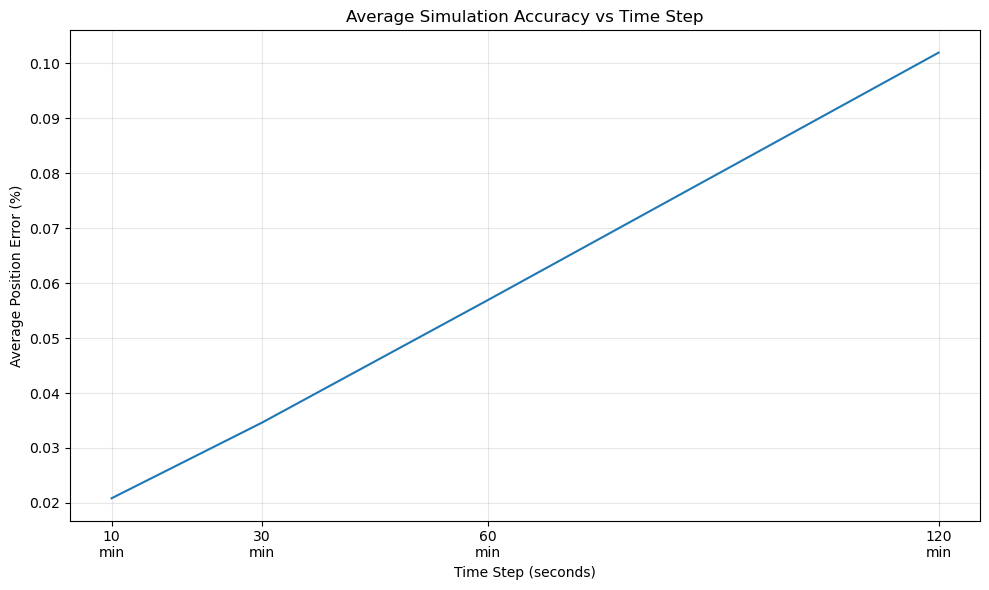

In [14]:
import matplotlib.pyplot as plt

#Test different time steps
#10 min, 30 min, 1 hour, 2 hours
dt_values = [600, 1800, 3600, 7200]  
avg_errors = []
planet_errors = {planet: [] for planet in ['Mercury', 'Venus', 'Earth', 'Mars']}

#NASA positions for Feb 12
nasa_positions = {
    'Mercury': vector(4.108214790190698e10, 2.569367279058727e10, -1.668206843795660e9),
    'Venus': vector(1.041562862697571e11, -3.088872807984433e10, -6.434136163114887e9),
    'Earth': vector(-1.177913150805354e11, 8.906050919494525e10, -4.243110684398562e6),
    'Mars': vector(1.323155944329624e11, -1.610424638534423e11, -6.619322785731733e9)
}

#For all time step values
for dt_test in dt_values:
    #Reset bodies to initial conditions
    for name, data in planets_data.items():
        bodies[name]['pos'] = data['pos']
        bodies[name]['vel'] = data['vel']
    
    #Run 10-day simulation
    ten_days = 10 * 24 * 3600
    t = 0
    
    #Main update loop
    while t < ten_days:
        update_velocities(bodies, dt_test)
        update_positions(bodies, dt_test)
        t += dt_test
    
    #Calculate errors for all planets
    total_error = 0
    for planet in ['Mercury', 'Venus', 'Earth', 'Mars']:
        sim_pos = bodies[planet]['pos']
        nasa_pos = nasa_positions[planet]
        error_distance = mag(sim_pos - nasa_pos)
        error_percent = (error_distance / mag(nasa_pos)) * 100
        planet_errors[planet].append(error_percent)
        total_error += error_percent
    
    #Calculate average error
    avg_error = total_error / 4
    avg_errors.append(avg_error)

#Create plot
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

#Plot the average error against the time steps
axes.plot(dt_values, avg_errors)
axes.set_xlabel('Time Step (seconds)')
axes.set_ylabel('Average Position Error (%)')
axes.set_title('Average Simulation Accuracy vs Time Step')
axes.grid(True, alpha=0.3)
axes.set_xticks(dt_values)
axes.set_xticklabels([f'{dt/60:.0f}\nmin' for dt in dt_values])

plt.tight_layout()
plt.show()


This figure created shows a clear increase into the error we introduce by increasing our time step. It looks as though there is a positive linear relationship between the time step and the error. If we keep the time step as low as possible, we can get the best results, but we may be sacrificing computational efficiency and if we are using it in a simulation, it could be too slow. For main simulation, a dt of 3600, or one hour, could be used as it created a fast, smooth visual, while still maintaining a high accuracy